In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\juned\Videos\data analytics\end to end projects\Ecommerce\Cleaned_eCommerce_data(CSV).csv")

In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,1,12,2010,Q4
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,1,12,2010,Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,1,12,2010,Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,1,12,2010,Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,1,12,2010,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...
397919,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20,9,12,2011,Q4
397920,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60,9,12,2011,Q4
397921,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60,9,12,2011,Q4
397922,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,16.60,9,12,2011,Q4


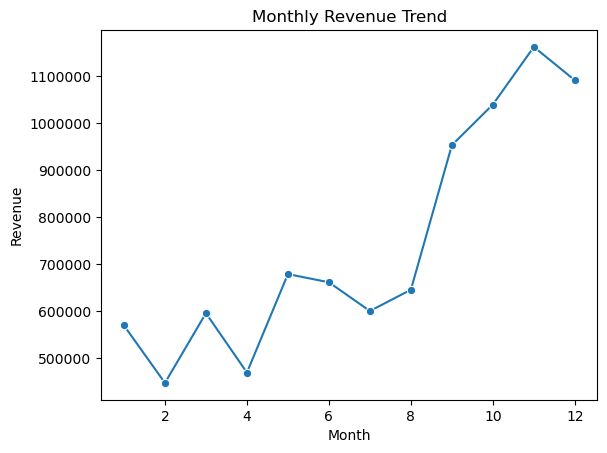

In [26]:
sns.lineplot(data=df, x='Month', y='Revenue', marker='o', estimator=np.sum, errorbar=None)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Monthly Revenue Trend')
plt.show()

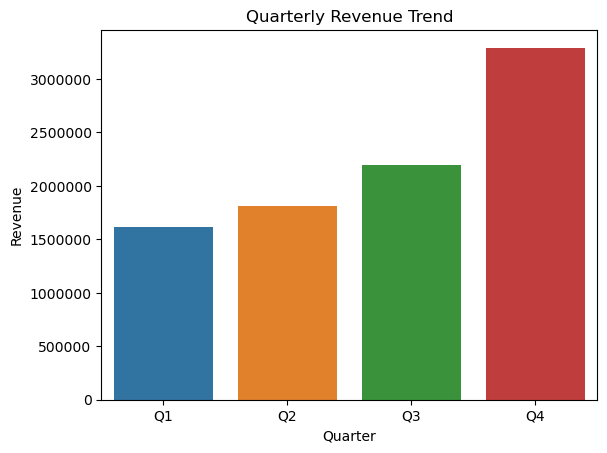

In [36]:
sortQuarter = df.sort_values('Quarter')
sns.barplot(data = sortQuarter, x = 'Quarter', y = 'Revenue', estimator = np.sum, hue='Quarter',errorbar=None)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Quarterly Revenue Trend')
plt.show()

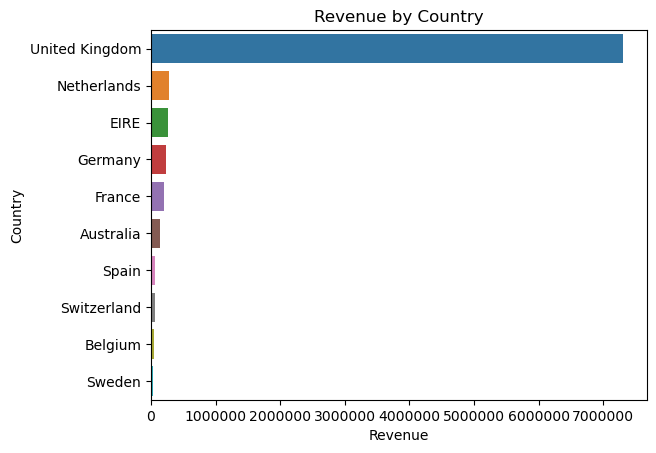

In [43]:
top10country = (df.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10).reset_index())
sns.barplot(data = top10country, x = 'Revenue', y = 'Country', estimator = np.sum, hue = 'Country')
plt.ticklabel_format(style='plain', axis='x')
plt.title('Revenue by Country')
plt.show()

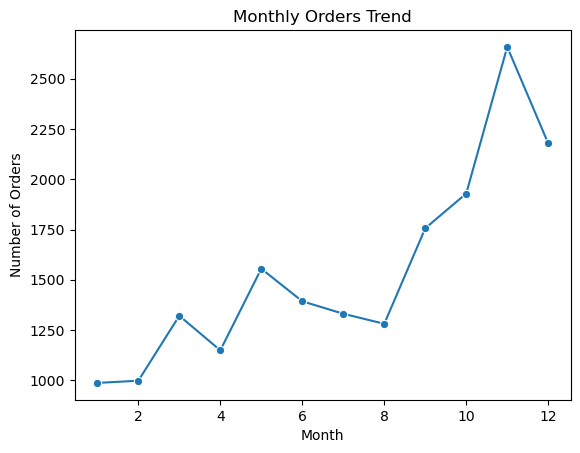

In [55]:
monthly_orders = df.groupby('Month')['InvoiceNo'].nunique().reset_index()
sns.lineplot( data=monthly_orders, x='Month', y='InvoiceNo',marker='o',estimator = np.sum)
plt.title('Monthly Orders Trend')
plt.ylabel('Number of Orders')
plt.show()

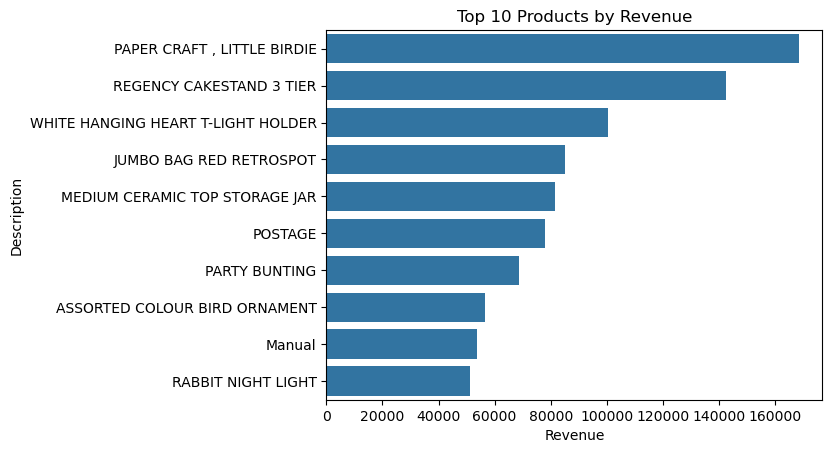

In [59]:
top10product = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index())

sns.barplot(data=top10product,x='Revenue',y='Description')

plt.ticklabel_format(style='plain', axis='x')
plt.title('Top 10 Products by Revenue')
plt.show()

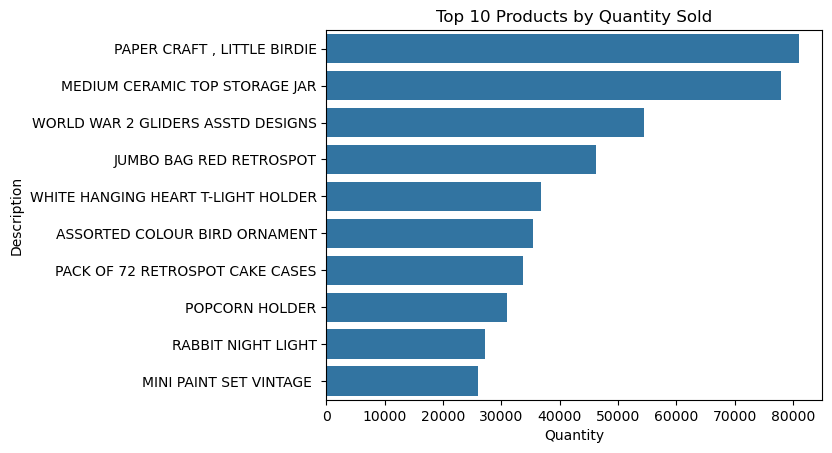

In [60]:
top10productbyquantity = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index())

sns.barplot(data=top10productbyquantity,x='Quantity',y='Description')

plt.ticklabel_format(style='plain', axis='x')
plt.title('Top 10 Products by Quantity Sold')
plt.show()

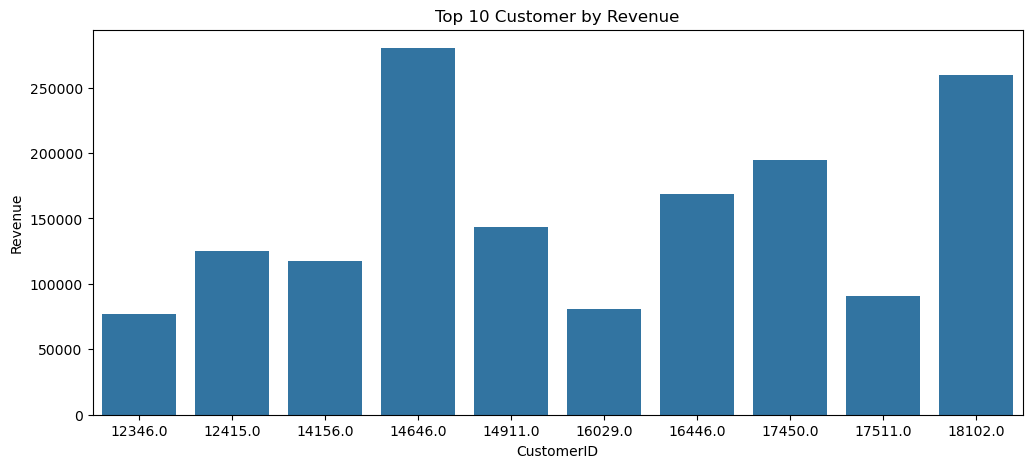

In [64]:
top10customer = (df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index())
plt.figure(figsize=(12,5))
sns.barplot(data=top10customer,x='CustomerID',y='Revenue')
plt.title('Top 10 Customer by Revenue')
plt.show()

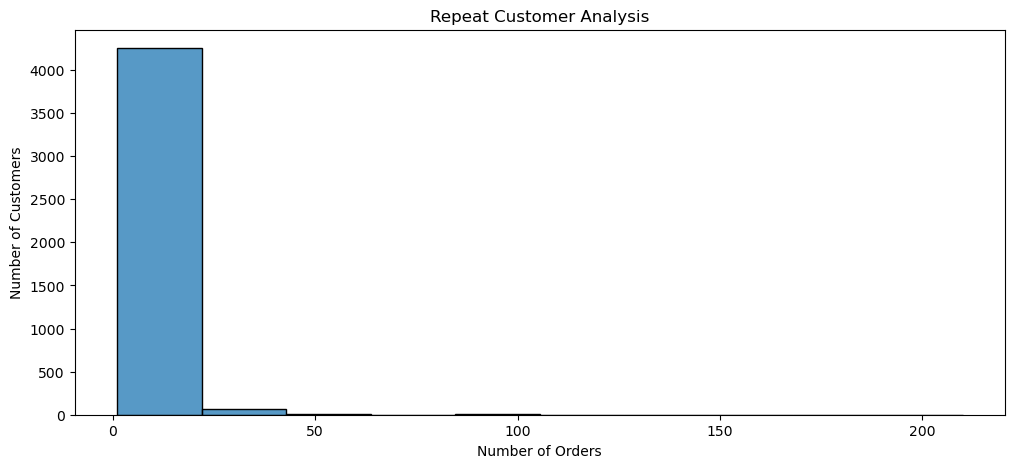

In [70]:
customerorder = (df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='OrderCount'))
plt.figure(figsize=(12,5))
sns.histplot(data=customerorder, x='OrderCount',  bins=10)
plt.title('Repeat Customer Analysis')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

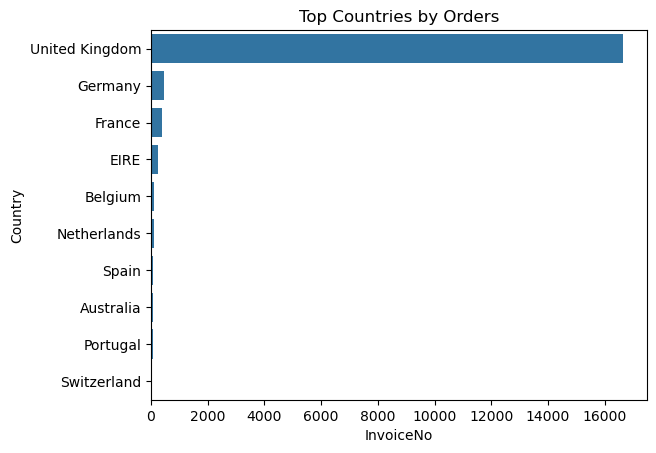

In [16]:
topcountries =df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=topcountries, x = 'InvoiceNo', y = 'Country')
plt.title('Top Countries by Orders')
plt.show()

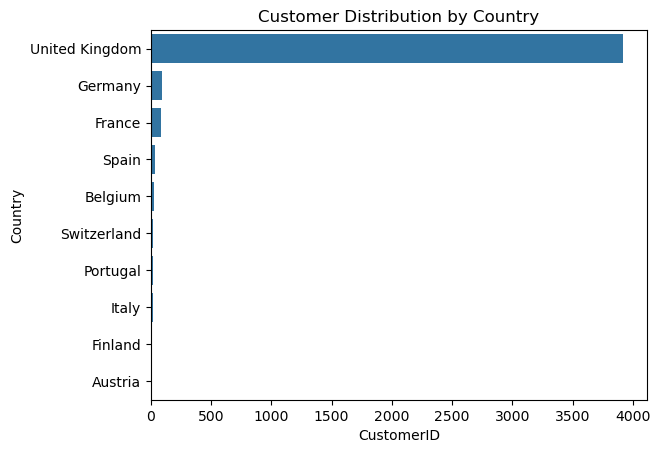

In [17]:
topcustomersfromcountries =df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=topcustomersfromcountries, x = 'CustomerID', y = 'Country')
plt.title('Customer Distribution by Country')
plt.show()

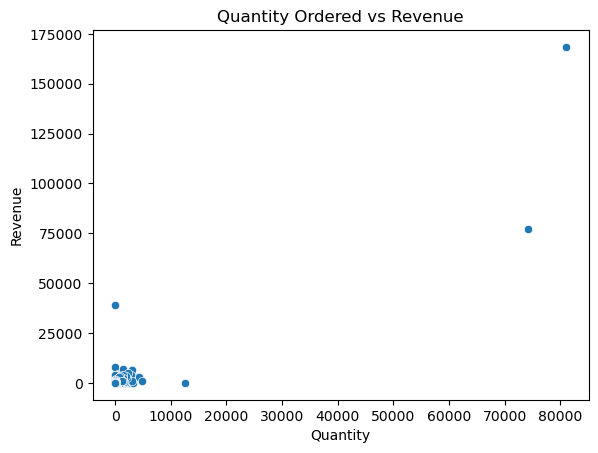

In [18]:
sns.scatterplot(data=df,x = 'Quantity', y="Revenue")
plt.title('Quantity Ordered vs Revenue')
plt.show()

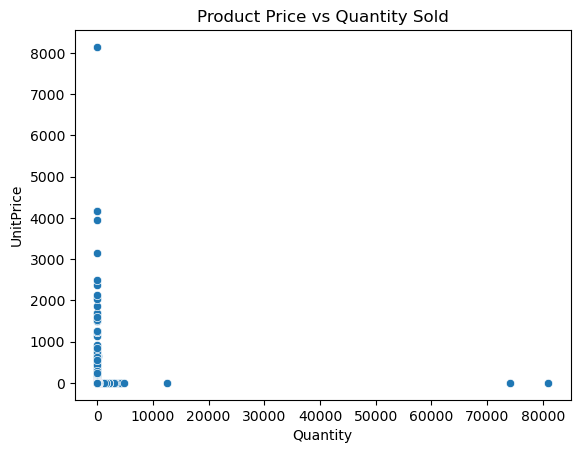

In [20]:
sns.scatterplot(data=df, x = "Quantity", y="UnitPrice")
plt.title('Product Price vs Quantity Sold')
plt.show()

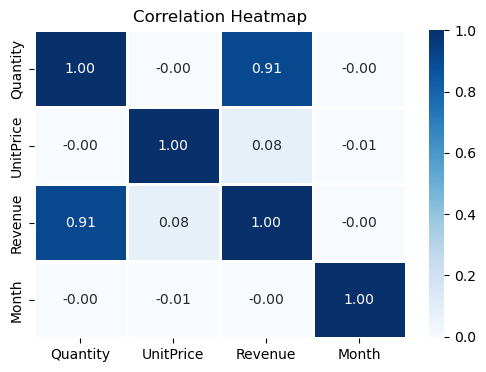

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(data=df[['Quantity','UnitPrice','Revenue','Month']].corr(), annot = True, cmap ='Blues',linewidth = 2, fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()